### Initial Mount and Req

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !pip install huggingface_hub nibabel matplotlib seaborn pandas numpy tqdm scikit-image

In [ ]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from huggingface_hub import snapshot_download, login
import random
from skimage import exposure
import time

In [ ]:
# !df -h /content
# print("\n")
# !nvidia-smi

### PED Data & Functions

##### Downloading PED

In [ ]:
from huggingface_hub import login
login()

In [ ]:
start_time = time.time()

snapshot_download(
    repo_id="Spirit-26/BraTS-2024-Complete",
    repo_type='dataset',
    allow_patterns="BraTS-PED/*",
    local_dir="/content/BraTS-2024-Complete",
    token=os.environ.get('HF_TOKEN')
)

end_time = time.time()
print(f"Download complete: {(end_time-start_time)/60:.2f} m")

Fetching ... files: 0it [00:00, ?it/s]

Download complete: 3.43 m


In [ ]:
base_path = "/content/BraTS-2024-Complete/BraTS-PED"

train_path = os.path.join(base_path, 'train')
val_path = os.path.join(base_path, 'val')

train_patients = [d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))]
val_patients = [d for d in os.listdir(val_path) if os.path.isdir(os.path.join(val_path, d))]

print(f"\n📊 BraTS-PED Dataset:")
print(f"  - Train patients: {len(train_patients)}")
print(f"  - Val patients: {len(val_patients)}")
print(f"  - Total: {len(train_patients) + len(val_patients)}")

print(f"\nSample train patient: {train_patients[0]}")
print(f"Sample val patient: {val_patients[0]}")


📊 BraTS-PED Dataset:
  - Train patients: 257
  - Val patients: 91
  - Total: 348

Sample train patient: BraTS-PED-00043-000
Sample val patient: BraTS-PED-00331-000


In [ ]:
def load_patient(patient_path):
    """Load all modalities for one patient"""
    modalities = {}

    files = os.listdir(patient_path)

    for f in files:
        if f.endswith('.nii.gz'):
            if 't1c' in f:
                modalities['t1ce'] = nib.load(os.path.join(patient_path, f)).get_fdata()
            elif 't1n' in f:
                modalities['t1'] = nib.load(os.path.join(patient_path, f)).get_fdata()
            elif 't2w' in f:
                modalities['t2'] = nib.load(os.path.join(patient_path, f)).get_fdata()
            elif 't2f' in f:
                modalities['flair'] = nib.load(os.path.join(patient_path, f)).get_fdata()
            elif 'seg' in f:
                modalities['seg'] = nib.load(os.path.join(patient_path, f)).get_fdata()

    return modalities


#### Load first train patient

In [ ]:
sample_patient = os.path.join(train_path, train_patients[0])
print(f"\nLoading: {train_patients[0]}")
data = load_patient(sample_patient)


Loading: BraTS-PED-00043-000


In [ ]:
for name, img in data.items():
    print(f"\n{name.upper()}:")
    print(f"  - Shape: {img.shape}")
    print(f"  - Data type: {img.dtype}")
    print(f"  - Min: {img.min():.2f}")
    print(f"  - Max: {img.max():.2f}")
    print(f"  - Mean: {img.mean():.2f}")
    print(f"  - Std: {img.std():.2f}")


SEG:
  - Shape: (240, 240, 155)
  - Data type: float64
  - Min: 0.00
  - Max: 4.00
  - Mean: 0.05
  - Std: 0.35

T1CE:
  - Shape: (240, 240, 155)
  - Data type: float64
  - Min: 0.00
  - Max: 747.49
  - Mean: 50.87
  - Std: 83.30

FLAIR:
  - Shape: (240, 240, 155)
  - Data type: float64
  - Min: 0.00
  - Max: 1402.32
  - Mean: 107.45
  - Std: 172.44

T2:
  - Shape: (240, 240, 155)
  - Data type: float64
  - Min: 0.00
  - Max: 1521.43
  - Mean: 120.58
  - Std: 220.19

T1:
  - Shape: (240, 240, 155)
  - Data type: float64
  - Min: 0.00
  - Max: 2004.82
  - Mean: 142.57
  - Std: 228.53


##### Plot Midddle Slices of all Modalities

In [ ]:
def plot_patient_slices(data, patient_id, slice_num=None):

    if slice_num is None:
        slice_num = data['t1'].shape[2] // 2

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Plot each modality
    modalities = ['t1', 't1ce', 't2', 'flair', 'seg']
    titles = ['T1', 'T1CE', 'T2', 'FLAIR', 'Segmentation']

    for i, (mod, title) in enumerate(zip(modalities, titles)):
        if mod in data:
            ax = axes[i//3, i%3]
            img_slice = data[mod][:, :, slice_num]

            if mod == 'seg':
                im = ax.imshow(img_slice.T, cmap='nipy_spectral', origin='lower',
                               interpolation='nearest')
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            else:
                im = ax.imshow(img_slice.T, cmap='gray', origin='lower')

            ax.set_title(f'{title} - Slice {slice_num}')
            ax.axis('off')

    # Remove empty subplot
    axes[1, 2].axis('off')

    plt.suptitle(f'Patient: {patient_id}', fontsize=16)
    plt.tight_layout()

    plt.savefig(f'/content/drive/MyDrive/BraTS_Project/figures/{patient_id}_sample.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return slice_num

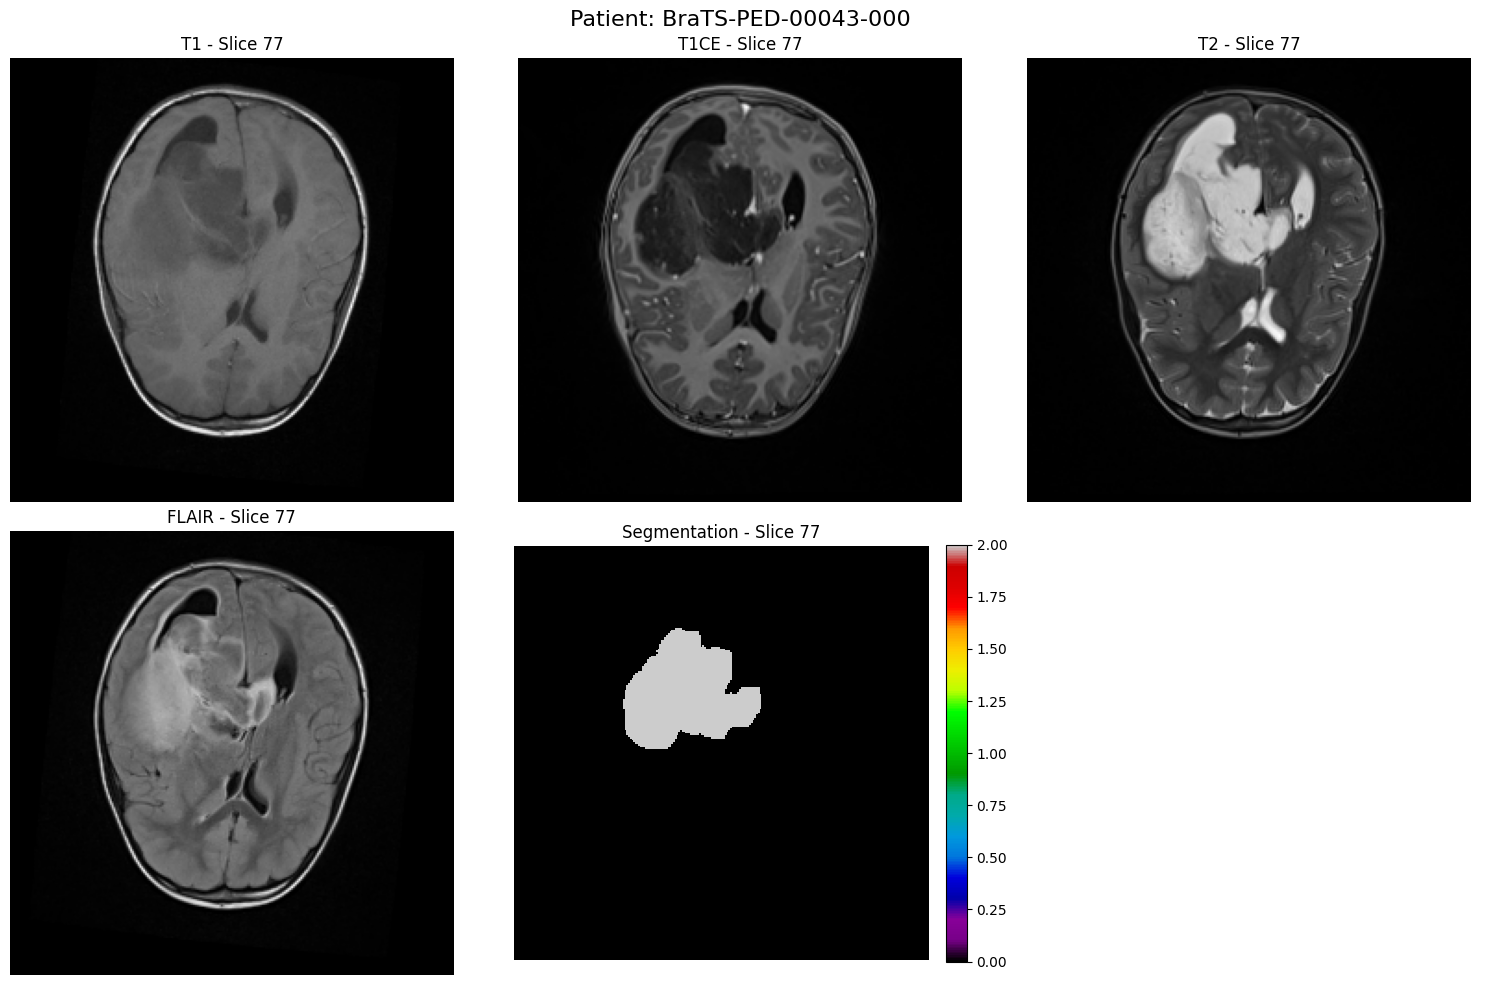

In [ ]:
slice_used = plot_patient_slices(data, train_patients[0])

#### Tumor Analysis

In [ ]:
def analyze_tumor(seg_data):
    unique, counts = np.unique(seg_data, return_counts=True)
    class_counts = dict(zip(unique, counts))

    tumor_voxels = np.sum(seg_data > 0)
    total_voxels = seg_data.size
    tumor_ratio = (tumor_voxels / total_voxels) * 100

    # Classification sz
    if tumor_voxels < 10000:
        size_class = 'Small (<10k)'
    elif tumor_voxels < 100000:
        size_class = 'Medium (10k-100k)'
    else:
        size_class = 'Large (>100k)'

    has_ET = 3 in unique
    has_ED = 2 in unique
    has_NCR = 1 in unique or 4 in unique

    return {
        'tumor_voxels': tumor_voxels,
        'tumor_ratio': tumor_ratio,
        'size_class': size_class,
        'has_ET': has_ET,
        'has_ED': has_ED,
        'has_NCR': has_NCR,
        'class_0': class_counts.get(0, 0),
        'class_1': class_counts.get(1, 0),
        'class_2': class_counts.get(2, 0),
        'class_3': class_counts.get(3, 0),
        'class_4': class_counts.get(4, 0),
    }

In [ ]:
if 'seg' in data:
    stats = analyze_tumor(data['seg'])
    print("\n Tumor Analysis for sample patient:")
    for key, value in stats.items():
        print(f"  - {key}: {value}")


 Tumor Analysis for sample patient:
  - tumor_voxels: 208302
  - tumor_ratio: 2.333131720430108
  - size_class: Large (>100k)
  - has_ET: False
  - has_ED: True
  - has_NCR: True
  - class_0: 8719698
  - class_1: 1
  - class_2: 183011
  - class_3: 0
  - class_4: 25290


#### Analyze patients

In [ ]:
def analyze_all_patients(patient_list, base_path, max_patients=50):
    results = []

    for patient in tqdm(patient_list[:max_patients], desc="Analyzing patients"):
        patient_path = os.path.join(base_path, patient)

        seg_file = None
        for f in os.listdir(patient_path):
            if 'seg' in f and f.endswith('.nii.gz'):
                seg_file = os.path.join(patient_path, f)
                break

        if seg_file:
            seg_data = nib.load(seg_file).get_fdata()
            stats = analyze_tumor(seg_data)
            stats['patient_id'] = patient
            results.append(stats)

    return pd.DataFrame(results)

testing 50

In [ ]:
train_df = analyze_all_patients(train_patients, train_path, max_patients=50)
print(train_df.head())

Analyzing patients: 100%|██████████| 50/50 [00:12<00:00,  4.05it/s]

   tumor_voxels  tumor_ratio         size_class  has_ET  has_ED  has_NCR  \
0        208302     2.333132      Large (>100k)   False    True     True   
1         10145     0.113631  Medium (10k-100k)   False    True    False   
2         75071     0.840849  Medium (10k-100k)    True    True    False   
3         24107     0.270016  Medium (10k-100k)   False    True    False   
4         10294     0.115300  Medium (10k-100k)   False    True    False   

   class_0  class_1  class_2  class_3  class_4           patient_id  
0  8719698        1   183011        0    25290  BraTS-PED-00043-000  
1  8917855        0    10145        0        0  BraTS-PED-00068-000  
2  8852929        0    73601     1470        0  BraTS-PED-00124-000  
3  8903893        0    24107        0        0  BraTS-PED-00253-000  
4  8917706        0    10294        0        0  BraTS-PED-00102-000  


In [ ]:
print("\nSTATISTICS:")
print(f"  - Patients with tumor: {len(train_df[train_df['tumor_voxels'] > 0])}")
print(f"  - Patients without tumor: {len(train_df[train_df['tumor_voxels'] == 0])}")

print(f"\nTumor volume:")
print(f"  - Mean: {train_df[train_df['tumor_voxels'] > 0]['tumor_voxels'].mean():,.0f}")
print(f"  - Median: {train_df[train_df['tumor_voxels'] > 0]['tumor_voxels'].median():,.0f}")
print(f"  - Min: {train_df[train_df['tumor_voxels'] > 0]['tumor_voxels'].min():,}")
print(f"  - Max: {train_df[train_df['tumor_voxels'] > 0]['tumor_voxels'].max():,}")

print(f"\nSize classes:")
print(train_df['size_class'].value_counts())

print(f"\nTumor compartments:")
print(f"  - ET present: {train_df['has_ET'].sum()}")
print(f"  - ED present: {train_df['has_ED'].sum()}")
print(f"  - NCR present: {train_df['has_NCR'].sum()}")


STATISTICS:
  - Patients with tumor: 50
  - Patients without tumor: 0

Tumor volume:
  - Mean: 45,283
  - Median: 29,252
  - Min: 854
  - Max: 208,302

Size classes:
size_class
Medium (10k-100k)    41
Large (>100k)         6
Small (<10k)          3
Name: count, dtype: int64

Tumor compartments:
  - ET present: 12
  - ED present: 50
  - NCR present: 30


##### VVL

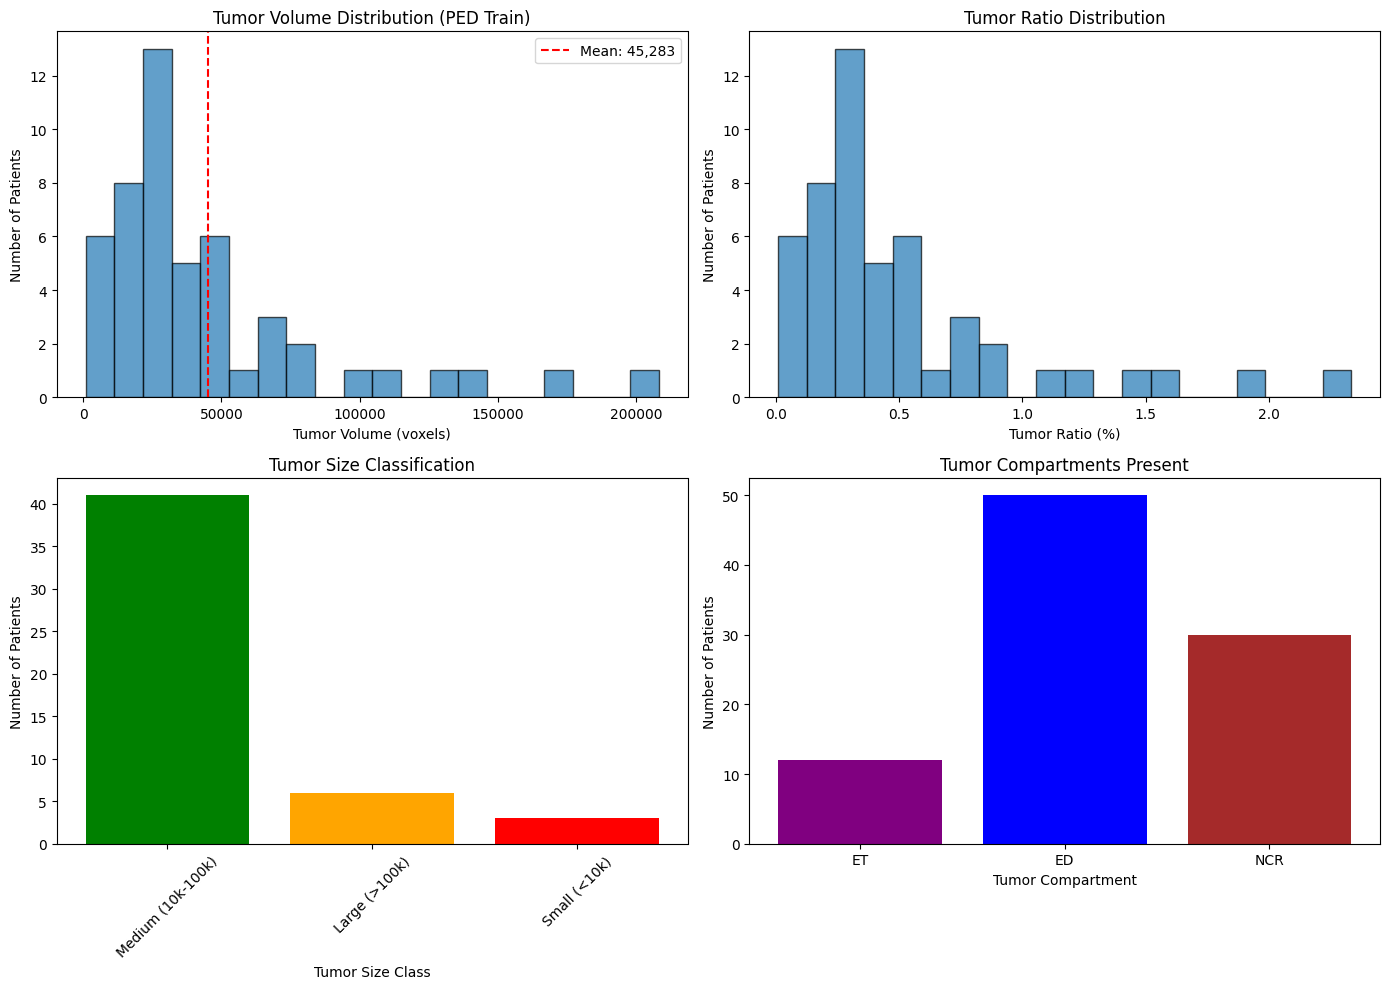

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Tumor volume distribution
ax = axes[0, 0]
tumor_patients = train_df[train_df['tumor_voxels'] > 0]
ax.hist(tumor_patients['tumor_voxels'], bins=20, edgecolor='black', alpha=0.7)
ax.set_xlabel('Tumor Volume (voxels)')
ax.set_ylabel('Number of Patients')
ax.set_title('Tumor Volume Distribution (PED Train)')
ax.axvline(tumor_patients['tumor_voxels'].mean(), color='red', linestyle='--', label=f'Mean: {tumor_patients["tumor_voxels"].mean():,.0f}')
ax.legend()

# 2. Tumor ratio
ax = axes[0, 1]
ax.hist(tumor_patients['tumor_ratio'], bins=20, edgecolor='black', alpha=0.7)
ax.set_xlabel('Tumor Ratio (%)')
ax.set_ylabel('Number of Patients')
ax.set_title('Tumor Ratio Distribution')

# 3. Size classes
ax = axes[1, 0]
size_counts = train_df['size_class'].value_counts()
ax.bar(size_counts.index, size_counts.values, color=['green', 'orange', 'red'])
ax.set_xlabel('Tumor Size Class')
ax.set_ylabel('Number of Patients')
ax.set_title('Tumor Size Classification')
ax.tick_params(axis='x', rotation=45)

# 4. Compartments
ax = axes[1, 1]
compartments = ['ET', 'ED', 'NCR']
counts = [train_df['has_ET'].sum(), train_df['has_ED'].sum(), train_df['has_NCR'].sum()]
ax.bar(compartments, counts, color=['purple', 'blue', 'brown'])
ax.set_xlabel('Tumor Compartment')
ax.set_ylabel('Number of Patients')
ax.set_title('Tumor Compartments Present')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/BraTS_Project/figures/ped_distribution.png', dpi=150)
plt.show()


#### Split

In [ ]:
random.seed(42)
print(f"Original validation patients: {len(val_patients)}")

# val to test
test_ratio = 0.3
test_count = int(len(val_patients) * test_ratio)

random.shuffle(val_patients)
test_patients = val_patients[:test_count]
new_val_patients = val_patients[test_count:]

print(f"New test patients: {len(test_patients)}")
print(f"New validation patients: {len(new_val_patients)}")


Original validation patients: 91
New test patients: 27
New validation patients: 64


In [ ]:
# Save patient lists
with open('/content/drive/MyDrive/BraTS_Project/patient_lists/ped_train.txt', 'w') as f:
    for p in train_patients:
        f.write(f"{p}\n")

with open('/content/drive/MyDrive/BraTS_Project/patient_lists/ped_val.txt', 'w') as f:
    for p in new_val_patients:
        f.write(f"{p}\n")

with open('/content/drive/MyDrive/BraTS_Project/patient_lists/ped_test.txt', 'w') as f:
    for p in test_patients:
        f.write(f"{p}\n")

In [ ]:
def preprocess_image(image):
    # Remove background (voxels with zero value)
    mask = image > 0
    if mask.sum() > 0:
        mean = image[mask].mean()
        std = image[mask].std()
        normalized = (image - mean) / (std + 1e-8)
        normalized[~mask] = 0
        return normalized
    else:
        return image

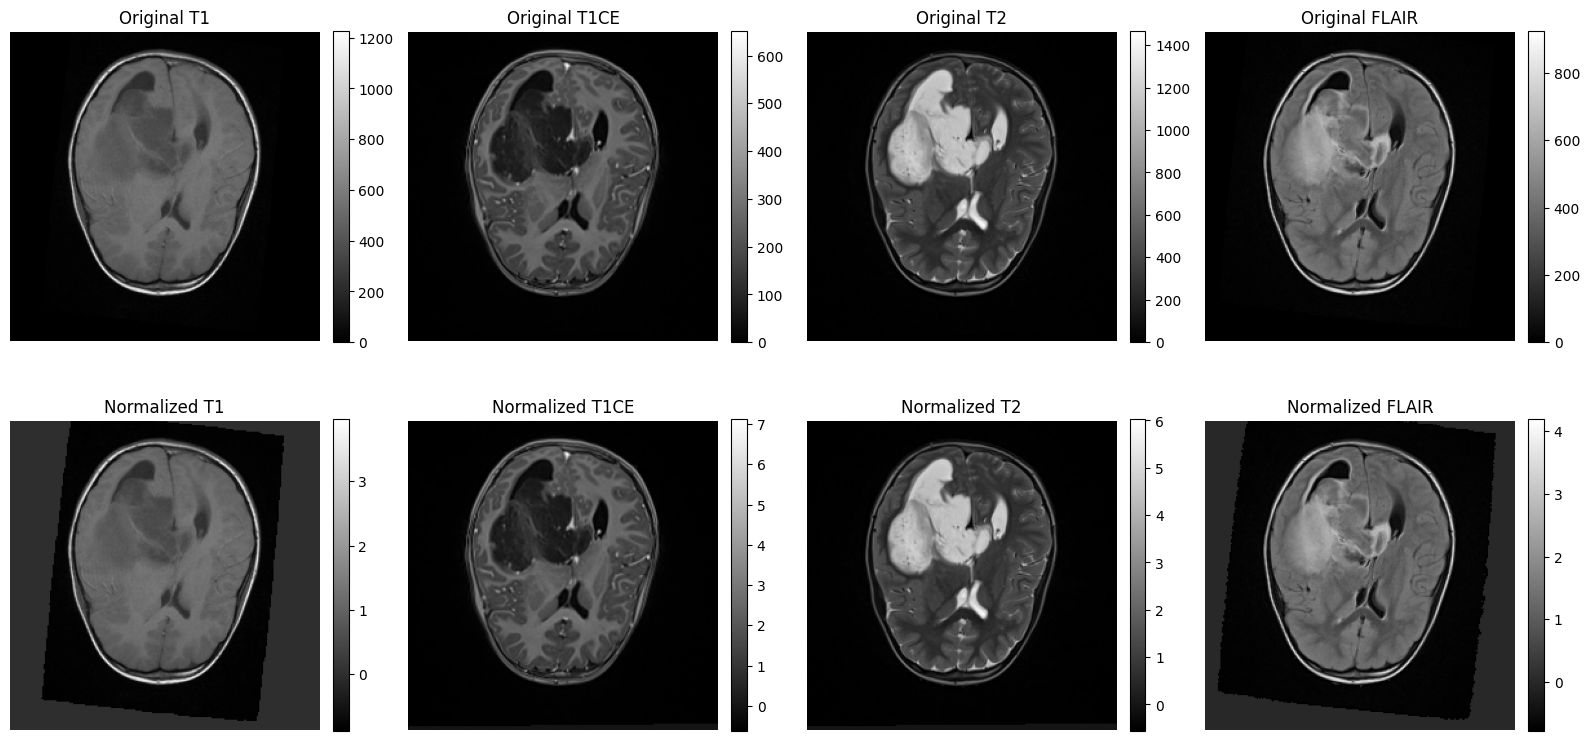

In [ ]:
#Test on sample
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

modalities = ['t1', 't1ce', 't2', 'flair']
slice_num = data['t1'].shape[2] // 2

for i, mod in enumerate(modalities):
    if mod in data:
        # Og
        ax = axes[0, i]
        img_slice = data[mod][:, :, slice_num]
        im = ax.imshow(img_slice.T, cmap='gray', origin='lower')
        ax.set_title(f'Original {mod.upper()}')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Prepd
        ax = axes[1, i]
        preprocessed = preprocess_image(data[mod])
        img_slice = preprocessed[:, :, slice_num]
        im = ax.imshow(img_slice.T, cmap='gray', origin='lower')
        ax.set_title(f'Normalized {mod.upper()}')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### MEN Data

In [ ]:
#!rm -rf /content/BraTS-2024-Complete/BraTS-PED
#!df -h /content

##### Downloading MEN

In [ ]:
snapshot_download(
    repo_id="Spirit-26/BraTS-2024-Complete",
    repo_type='dataset',
    allow_patterns="BraTS-MEN-RT/*",
    local_dir="/content/BraTS-2024-Complete",
    token=os.environ.get('HF_TOKEN')
)

Fetching ... files: 0it [00:00, ?it/s]

'/content/BraTS-2024-Complete'

In [ ]:
men_base = "/content/BraTS-2024-Complete/BraTS-MEN-RT"
men_train_path = os.path.join(men_base, 'train')
men_val_path = os.path.join(men_base, 'val')

men_train_patients = [d for d in os.listdir(men_train_path) if os.path.isdir(os.path.join(men_train_path, d))]
men_val_patients = [d for d in os.listdir(men_val_path) if os.path.isdir(os.path.join(men_val_path, d))]

print(f"\nBraTS-MEN Dataset:")
print(f"  - Train patients: {len(men_train_patients)}")
print(f"  - Val patients: {len(men_val_patients)}")
print(f"  - Total: {len(men_train_patients) + len(men_val_patients)}")
print(f"\nSample train patient: {men_train_patients[0]}")
print(f"Sample val patient: {men_val_patients[0]}")


BraTS-MEN Dataset:
  - Train patients: 500
  - Val patients: 70
  - Total: 570

Sample train patient: BraTS-MEN-RT-0394-1
Sample val patient: BraTS-MEN-RT-0595-1


#### Load first sample pt

In [ ]:
# sample_men_patient = os.path.join(men_train_path, men_train_patients[0])
# print(f"\nLoading: {men_train_patients[0]}")
# men_data = load_patient(sample_men_patient)

# for name, img in men_data.items():
#     print(f"\n{name.upper()}:")
#     print(f"  - Shape: {img.shape}")
#     print(f"  - Min: {img.min():.2f}")
#     print(f"  - Max: {img.max():.2f}")
#     print(f"  - Mean: {img.mean():.2f}")

# slice_used = plot_patient_slices(men_data, men_train_patients[0])


Loading: BraTS-MEN-RT-0394-1

T1CE:
  - Shape: (256, 256, 172)
  - Min: 0.00
  - Max: 3036.00
  - Mean: 205.02


KeyError: 't1'

only t1ce

In [ ]:
sample_men_patient = os.path.join(men_train_path, men_train_patients[0])
print(f"{men_train_patients[0]}")
men_data = load_patient(sample_men_patient)

print(f"\nAvl modalities: {list(men_data.keys())}")

for name, img in men_data.items():
    print(f"\n{name.upper()}:")
    print(f"  - Shape: {img.shape}")
    print(f"  - Min: {img.min():.2f}")
    print(f"  - Max: {img.max():.2f}")
    print(f"  - Mean: {img.mean():.2f}")

BraTS-MEN-RT-0394-1

Avl modalities: ['t1ce']

T1CE:
  - Shape: (256, 256, 172)
  - Min: 0.00
  - Max: 3036.00
  - Mean: 205.02


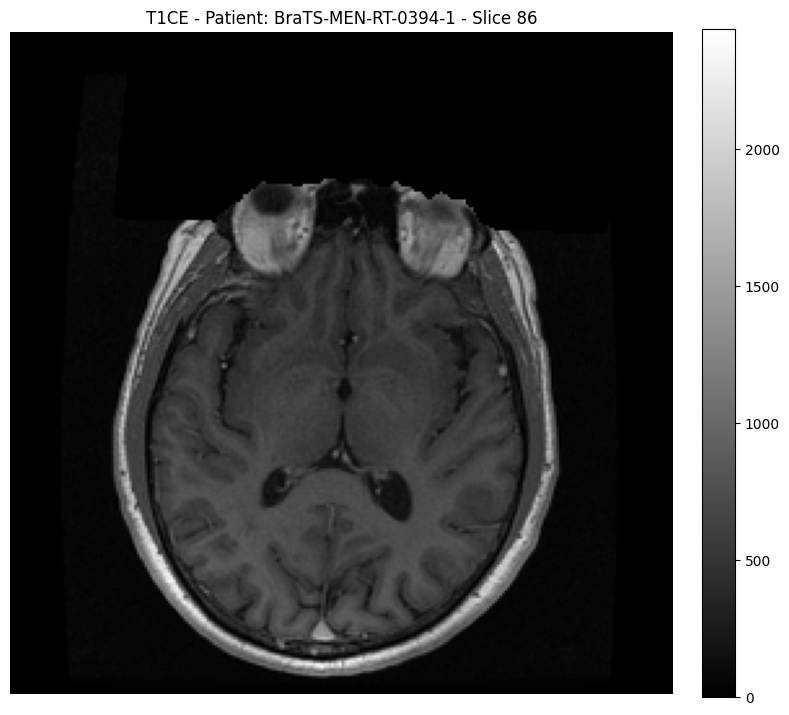

In [ ]:
def plot_men_patient(data, patient_id):
    first_key = list(data.keys())[0]
    slice_num = data[first_key].shape[2] // 2

    img_slice = data['t1ce'][:, :, slice_num]

    plt.figure(figsize=(8, 8))
    plt.imshow(img_slice.T, cmap='gray', origin='lower')
    plt.title(f'T1CE - Patient: {patient_id} - Slice {slice_num}')
    plt.axis('off')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()

    plt.savefig(f'/content/drive/MyDrive/BraTS_Project/figures/men_{patient_id}_t1ce.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return slice_num

slice_used = plot_men_patient(men_data, men_train_patients[0])

men_base = "/content/BraTS-2024-Complete/BraTS-MEN-RT"

men_train_path = os.path.join(men_base, 'train')

men_val_path = os.path.join(men_base, 'val')

###### new analyse w/o seg

In [ ]:
def analyze_all_patients(patient_list, base_path, max_patients=50, label_keywords=('seg', 'gtv')):
    results = []
    skipped = 0

    for patient in tqdm(patient_list[:max_patients], desc="Analyzing patients"):
        patient_path = os.path.join(base_path, patient)

        label_file = None
        for f in os.listdir(patient_path):
            f_lower = f.lower()
            if f_lower.endswith('.nii.gz') and any(k in f_lower for k in label_keywords):
                label_file = os.path.join(patient_path, f)
                break

        if label_file:
            label_data = nib.load(label_file).get_fdata()
            stats = analyze_tumor(label_data)
            stats['patient_id'] = patient
            stats['label_file'] = os.path.basename(label_file)
            results.append(stats)
        else:
            skipped += 1

    if skipped > 0:
        print(f"Skipped {skipped} patients (no label file matched {label_keywords}).")

    return pd.DataFrame(results)

In [ ]:
men_train_df = analyze_all_patients(men_train_patients, men_train_path, max_patients=50)
print(men_train_df.head())

Analyzing patients: 100%|██████████| 50/50 [01:47<00:00,  2.14s/it]

   tumor_voxels  tumor_ratio         size_class  has_ET  has_ED  has_NCR  \
0         21005     0.186344  Medium (10k-100k)   False   False     True   
1         27133     0.240707  Medium (10k-100k)   False   False     True   
2          3821     0.047019       Small (<10k)   False   False     True   
3         25172     0.034172  Medium (10k-100k)   False   False     True   
4          6735     0.063437       Small (<10k)   False   False     True   

    class_0  class_1  class_2  class_3  class_4           patient_id  \
0  11251187    21005        0        0        0  BraTS-MEN-RT-0394-1   
1  11245059    27133        0        0        0  BraTS-MEN-RT-0392-1   
2   8122643     3821        0        0        0  BraTS-MEN-RT-0164-1   
3  73637292    25172        0        0        0  BraTS-MEN-RT-0077-1   
4  10610097     6735        0        0        0  BraTS-MEN-RT-0148-1   

                       label_file  
0  BraTS-MEN-RT-0394-1_gtv.nii.gz  
1  BraTS-MEN-RT-0392-1_gtv.nii.gz  
2 

In [ ]:
  print("\nSTATISTICS:")
print(f"  - Patients with tumor: {len(men_train_df[men_train_df['tumor_voxels'] > 0])}")
print(f"  - Patients without tumor: {len(men_train_df[men_train_df['tumor_voxels'] == 0])}")

print(f"\nTumor volume:")
print(f"  - Mean: {men_train_df[men_train_df['tumor_voxels'] > 0]['tumor_voxels'].mean():,.0f}")
print(f"  - Median: {men_train_df[men_train_df['tumor_voxels'] > 0]['tumor_voxels'].median():,.0f}")
print(f"  - Min: {men_train_df[men_train_df['tumor_voxels'] > 0]['tumor_voxels'].min():,}")
print(f"  - Max: {men_train_df[men_train_df['tumor_voxels'] > 0]['tumor_voxels'].max():,}")

print(f"\nSize classes:")
print(men_train_df['size_class'].value_counts())

print(f"\nTumor compartments:")
print(f"  - ET present: {men_train_df['has_ET'].sum()}")
print(f"  - ED present: {men_train_df['has_ED'].sum()}")
print(f"  - NCR present: {men_train_df['has_NCR'].sum()}")


STATISTICS:
  - Patients with tumor: 50
  - Patients without tumor: 0

Tumor volume:
  - Mean: 29,028
  - Median: 18,022
  - Min: 926
  - Max: 334,201

Size classes:
size_class
Medium (10k-100k)    30
Small (<10k)         18
Large (>100k)         2
Name: count, dtype: int64

Tumor compartments:
  - ET present: 0
  - ED present: 0
  - NCR present: 50


#### Visualize

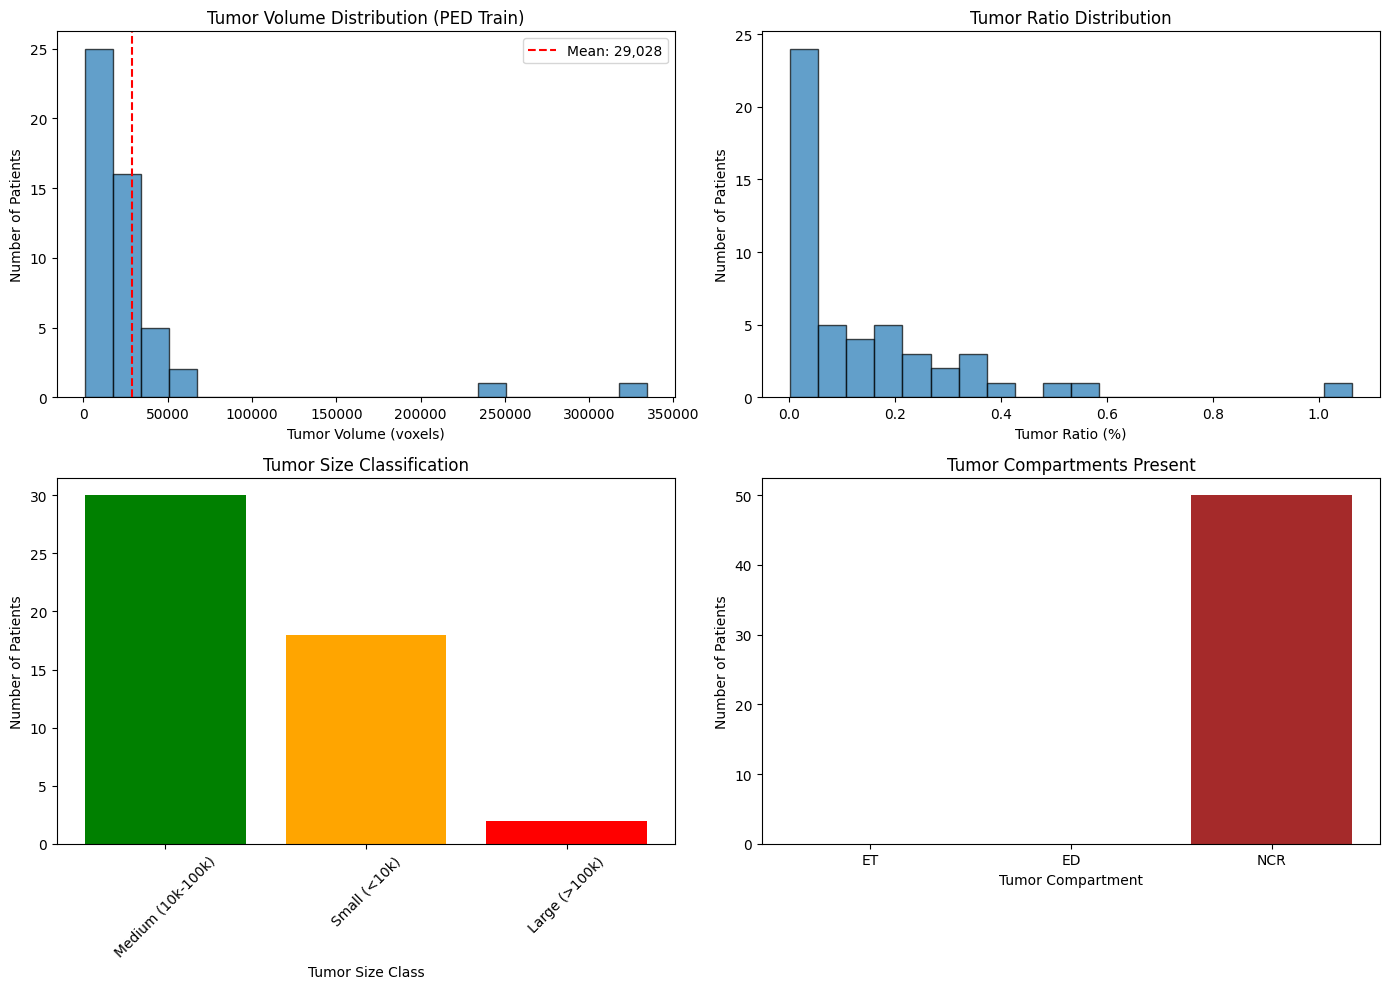

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Tumor volume distribution
ax = axes[0, 0]
tumor_patients = men_train_df[men_train_df['tumor_voxels'] > 0]
ax.hist(tumor_patients['tumor_voxels'], bins=20, edgecolor='black', alpha=0.7)
ax.set_xlabel('Tumor Volume (voxels)')
ax.set_ylabel('Number of Patients')
ax.set_title('Tumor Volume Distribution (PED Train)')
ax.axvline(tumor_patients['tumor_voxels'].mean(), color='red', linestyle='--', label=f'Mean: {tumor_patients["tumor_voxels"].mean():,.0f}')
ax.legend()

# 2. Tumor ratio
ax = axes[0, 1]
ax.hist(tumor_patients['tumor_ratio'], bins=20, edgecolor='black', alpha=0.7)
ax.set_xlabel('Tumor Ratio (%)')
ax.set_ylabel('Number of Patients')
ax.set_title('Tumor Ratio Distribution')

# 3. Size classes
ax = axes[1, 0]
size_counts = men_train_df['size_class'].value_counts()
ax.bar(size_counts.index, size_counts.values, color=['green', 'orange', 'red'])
ax.set_xlabel('Tumor Size Class')
ax.set_ylabel('Number of Patients')
ax.set_title('Tumor Size Classification')
ax.tick_params(axis='x', rotation=45)

# 4. Compartments
ax = axes[1, 1]
compartments = ['ET', 'ED', 'NCR']
counts = [men_train_df['has_ET'].sum(), men_train_df['has_ED'].sum(), men_train_df['has_NCR'].sum()]
ax.bar(compartments, counts, color=['purple', 'blue', 'brown'])
ax.set_xlabel('Tumor Compartment')
ax.set_ylabel('Number of Patients')
ax.set_title('Tumor Compartments Present')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/BraTS_Project/figures/men_distribution.png', dpi=150)
plt.show()


#### Split

In [27]:
random.seed(42)
print(f"Original MEN validation patients: {len(men_val_patients)}")

test_ratio = 0.3
test_count = int(len(men_val_patients) * test_ratio)

men_val_shuffled = men_val_patients.copy()
random.shuffle(men_val_shuffled)
men_test_patients = men_val_shuffled[:test_count]
men_new_val_patients = men_val_shuffled[test_count:]

print(f"MEN test patients: {len(men_test_patients)}")
print(f"MEN new validation patients: {len(men_new_val_patients)}")

Original MEN validation patients: 70
MEN test patients: 21
MEN new validation patients: 49


In [28]:
patient_list_dir = '/content/drive/MyDrive/BraTS_Project/patient_lists'
os.makedirs(patient_list_dir, exist_ok=True)

with open(os.path.join(patient_list_dir, 'men_train.txt'), 'w') as f:
    for p in men_train_patients:
        f.write(f"{p}\n")

with open(os.path.join(patient_list_dir, 'men_val.txt'), 'w') as f:
    for p in men_new_val_patients:
        f.write(f"{p}\n")

with open(os.path.join(patient_list_dir, 'men_test.txt'), 'w') as f:
    for p in men_test_patients:
        f.write(f"{p}\n")

print("Saved MEN patient lists: men_train.txt, men_val.txt, men_test.txt")

Saved MEN patient lists: men_train.txt, men_val.txt, men_test.txt


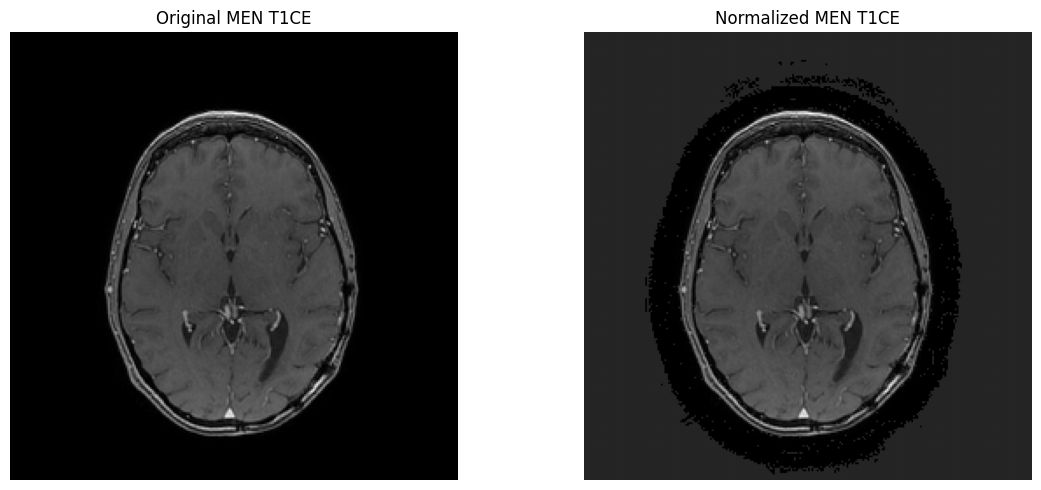

In [29]:
sample_men_patient = os.path.join(men_train_path, men_train_patients[0])
men_data = load_patient(sample_men_patient)

if 't1ce' not in men_data:
    raise ValueError("t1ce modality not found for MEN sample patient")

t1ce_img = men_data['t1ce']
slice_num = t1ce_img.shape[2] // 2
t1ce_norm = preprocess_image(t1ce_img)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(t1ce_img[:, :, slice_num].T, cmap='gray', origin='lower')
axes[0].set_title('Original MEN T1CE')
axes[0].axis('off')

axes[1].imshow(t1ce_norm[:, :, slice_num].T, cmap='gray', origin='lower')
axes[1].set_title('Normalized MEN T1CE')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/BraTS_Project/figures/MEN-preprocessing_test.png', dpi=150, bbox_inches='tight')
plt.show()

### GLI Data

In [30]:
# !rm -rf /content/BraTS-2024-Complete/BraTS-MEN
# !df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   34G   75G  32% /


#### Downloading PED

In [31]:
snapshot_download(
    repo_id="Spirit-26/BraTS-2024-Complete",
    repo_type='dataset',
    allow_patterns="BraTS-GLI/*",
    local_dir="/content/BraTS-2024-Complete",
    token=os.environ.get('HF_TOKEN')
)

Fetching ... files: 0it [00:00, ?it/s]

'/content/BraTS-2024-Complete'

In [32]:
gli_base = "/content/BraTS-2024-Complete/BraTS-GLI"
gli_train_path = os.path.join(gli_base, 'train')
gli_val_path = os.path.join(gli_base, 'val')

gli_train_patients = [d for d in os.listdir(gli_train_path) if os.path.isdir(os.path.join(gli_train_path, d))]
gli_val_patients = [d for d in os.listdir(gli_val_path) if os.path.isdir(os.path.join(gli_val_path, d))]

print(f"\nBraTS-GLI Dataset:")
print(f"  - Train patients: {len(gli_train_patients)}")
print(f"  - Val patients: {len(gli_val_patients)}")
print(f"  - Total: {len(gli_train_patients) + len(gli_val_patients)}")
print(f"\nSample train patient: {gli_train_patients[0]}")
print(f"Sample val patient: {gli_val_patients[0]}")


BraTS-GLI Dataset:
  - Train patients: 1621
  - Val patients: 188
  - Total: 1809

Sample train patient: BraTS-GLI-02243-101
Sample val patient: BraTS-GLI-02611-101


#### Load first sample patient

In [33]:
sample_gli_patient = os.path.join(gli_train_path, gli_train_patients[0])
print(f"\nLoading: {gli_train_patients[0]}")
gli_data = load_patient(sample_gli_patient)

for name, img in gli_data.items():
    print(f"\n{name.upper()}:")
    print(f"  - Shape: {img.shape}")
    print(f"  - Min: {img.min():.2f}")
    print(f"  - Max: {img.max():.2f}")
    print(f"  - Mean: {img.mean():.2f}")


Loading: BraTS-GLI-02243-101

T1:
  - Shape: (182, 218, 182)
  - Min: 0.00
  - Max: 1571.84
  - Mean: 75.71

T2:
  - Shape: (182, 218, 182)
  - Min: 0.00
  - Max: 1612.16
  - Mean: 97.19

T1CE:
  - Shape: (182, 218, 182)
  - Min: 0.00
  - Max: 1984.09
  - Mean: 84.52

SEG:
  - Shape: (182, 218, 182)
  - Min: 0.00
  - Max: 4.00
  - Mean: 0.01

FLAIR:
  - Shape: (182, 218, 182)
  - Min: 0.00
  - Max: 219.99
  - Mean: 25.07


### Aalyse Tumor

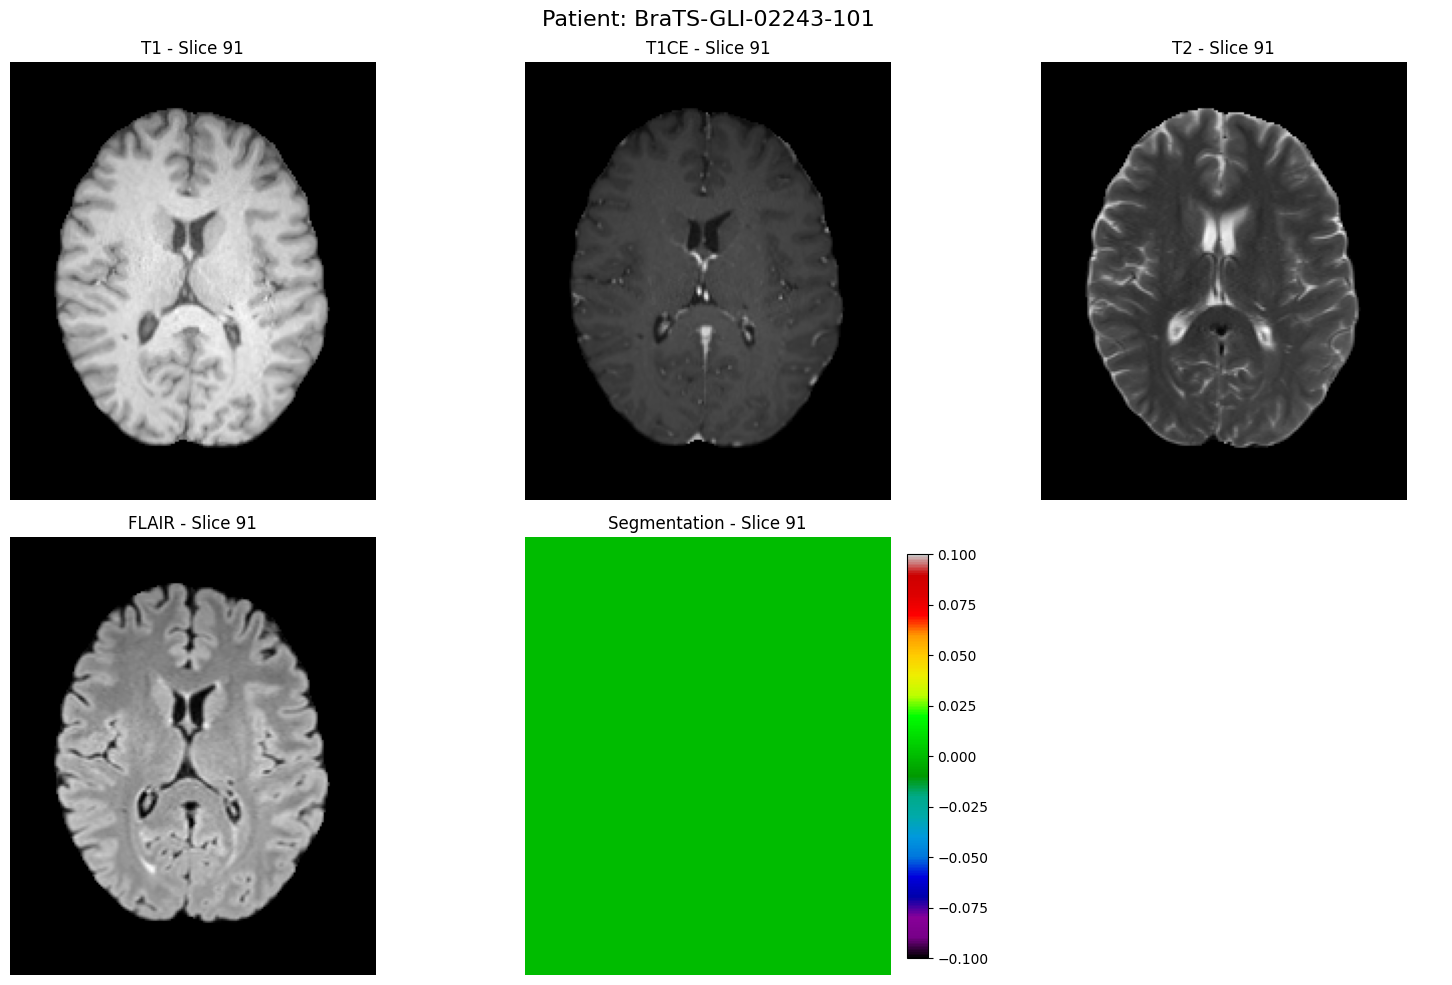

In [34]:
slice_used = plot_patient_slices(gli_data, gli_train_patients[0])

In [35]:
if 'seg' in gli_data:
    stats = analyze_tumor(gli_data['seg'])
    print("\n Tumor Analysis for sample patient:")
    for key, value in stats.items():
        print(f"  - {key}: {value}")

# Train 50
train_df = analyze_all_patients(gli_train_patients, gli_train_path, max_patients=50)
print(train_df.head())


 Tumor Analysis for sample patient:
  - tumor_voxels: 28690
  - tumor_ratio: 0.3973116308029102
  - size_class: Medium (10k-100k)
  - has_ET: True
  - has_ED: True
  - has_NCR: True
  - class_0: 7192342
  - class_1: 0
  - class_2: 13583
  - class_3: 2
  - class_4: 15105



Analyzing patients: 100%|██████████| 50/50 [00:16<00:00,  2.95it/s]

   tumor_voxels  tumor_ratio         size_class  has_ET  has_ED  has_NCR  \
0         28690     0.397312  Medium (10k-100k)    True    True     True   
1         76100     1.053866  Medium (10k-100k)    True    True     True   
2         27661     0.383062  Medium (10k-100k)    True    True     True   
3        103371     1.431527      Large (>100k)    True    True     True   
4         33080     0.458106  Medium (10k-100k)    True    True     True   

   class_0  class_1  class_2  class_3  class_4           patient_id  \
0  7192342        0    13583        2    15105  BraTS-GLI-02243-101   
1  7144932        0    38115      675    37310  BraTS-GLI-02093-105   
2  7193371        0    18266      709     8686  BraTS-GLI-03031-100   
3  7117661     6725    25259    70152     1235  BraTS-GLI-00533-101   
4  7187952       60    26915     4593     1512  BraTS-GLI-02763-101   

                       label_file  
0  BraTS-GLI-02243-101-seg.nii.gz  
1  BraTS-GLI-02093-105-seg.nii.gz  
2  BraTS

In [36]:
print("\nSTATISTICS:")
print(f"  - Patients with tumor: {len(train_df[train_df['tumor_voxels'] > 0])}")
print(f"  - Patients without tumor: {len(train_df[train_df['tumor_voxels'] == 0])}")

print(f"\nTumor volume:")
print(f"  - Mean: {train_df[train_df['tumor_voxels'] > 0]['tumor_voxels'].mean():,.0f}")
print(f"  - Median: {train_df[train_df['tumor_voxels'] > 0]['tumor_voxels'].median():,.0f}")
print(f"  - Min: {train_df[train_df['tumor_voxels'] > 0]['tumor_voxels'].min():,}")
print(f"  - Max: {train_df[train_df['tumor_voxels'] > 0]['tumor_voxels'].max():,}")

print(f"\nSize classes:")
print(train_df['size_class'].value_counts())

print(f"\nTumor compartments:")
print(f"  - ET present: {train_df['has_ET'].sum()}")
print(f"  - ED present: {train_df['has_ED'].sum()}")
print(f"  - NCR present: {train_df['has_NCR'].sum()}")


STATISTICS:
  - Patients with tumor: 50
  - Patients without tumor: 0

Tumor volume:
  - Mean: 73,984
  - Median: 56,866
  - Min: 11,925
  - Max: 264,615

Size classes:
size_class
Medium (10k-100k)    38
Large (>100k)        12
Name: count, dtype: int64

Tumor compartments:
  - ET present: 43
  - ED present: 50
  - NCR present: 49


### Visualize

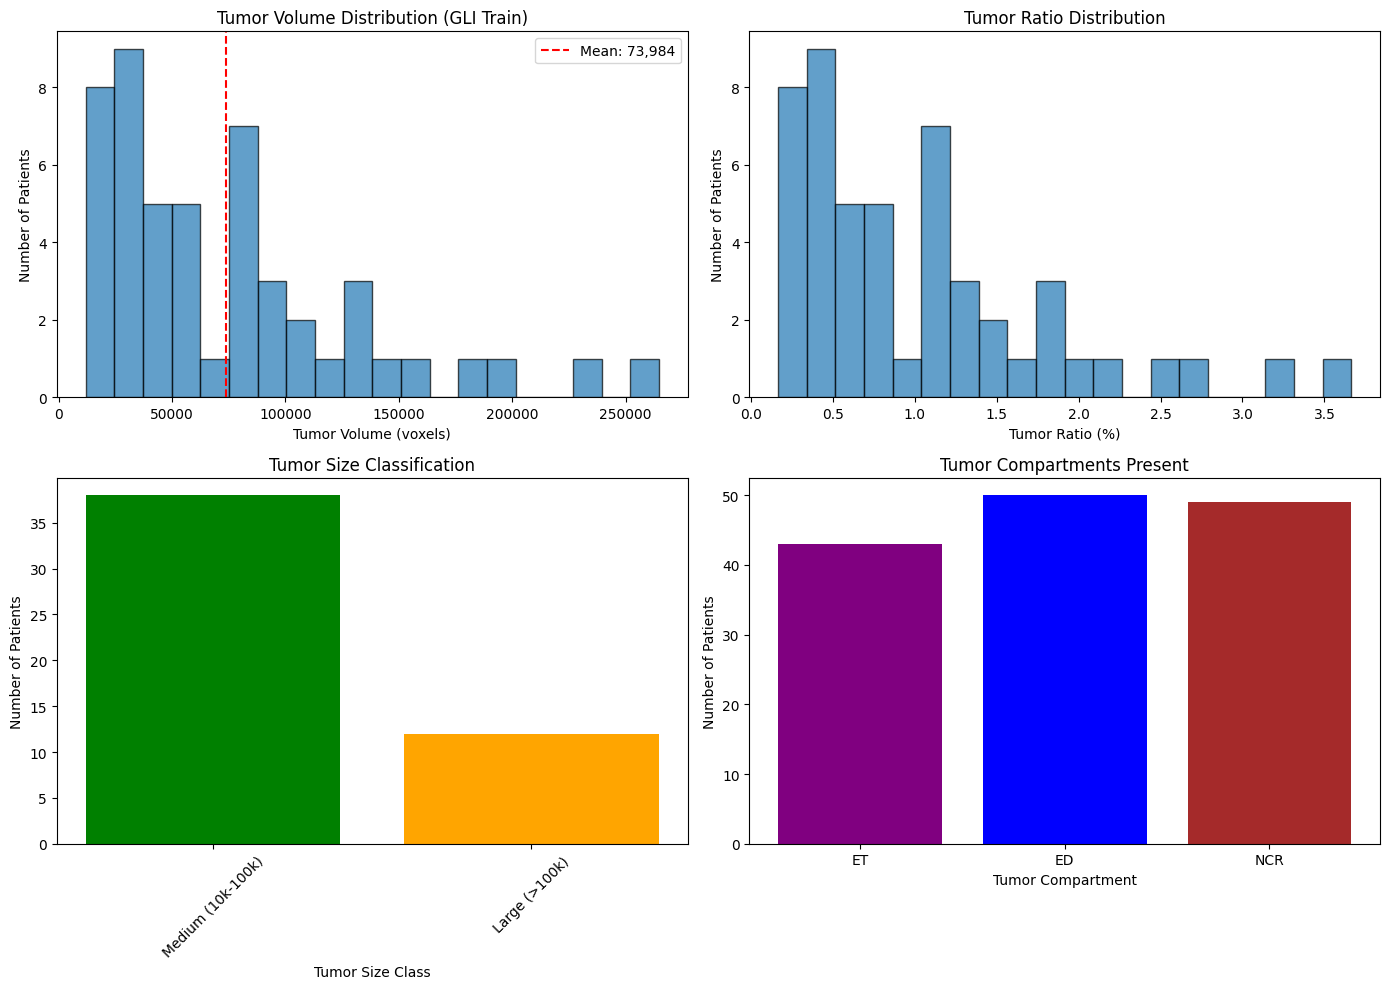

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Tumor volume distribution
ax = axes[0, 0]
tumor_patients = train_df[train_df['tumor_voxels'] > 0]
ax.hist(tumor_patients['tumor_voxels'], bins=20, edgecolor='black', alpha=0.7)
ax.set_xlabel('Tumor Volume (voxels)')
ax.set_ylabel('Number of Patients')
ax.set_title('Tumor Volume Distribution (GLI Train)')
ax.axvline(tumor_patients['tumor_voxels'].mean(), color='red', linestyle='--', label=f'Mean: {tumor_patients["tumor_voxels"].mean():,.0f}')
ax.legend()

# 2. Tumor ratio
ax = axes[0, 1]
ax.hist(tumor_patients['tumor_ratio'], bins=20, edgecolor='black', alpha=0.7)
ax.set_xlabel('Tumor Ratio (%)')
ax.set_ylabel('Number of Patients')
ax.set_title('Tumor Ratio Distribution')

# 3. Size classes
ax = axes[1, 0]
size_counts = train_df['size_class'].value_counts()
ax.bar(size_counts.index, size_counts.values, color=['green', 'orange', 'red'])
ax.set_xlabel('Tumor Size Class')
ax.set_ylabel('Number of Patients')
ax.set_title('Tumor Size Classification')
ax.tick_params(axis='x', rotation=45)

# 4. Compartments
ax = axes[1, 1]
compartments = ['ET', 'ED', 'NCR']
counts = [train_df['has_ET'].sum(), train_df['has_ED'].sum(), train_df['has_NCR'].sum()]
ax.bar(compartments, counts, color=['purple', 'blue', 'brown'])
ax.set_xlabel('Tumor Compartment')
ax.set_ylabel('Number of Patients')
ax.set_title('Tumor Compartments Present')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/BraTS_Project/figures/gli_distribution.png', dpi=150)
plt.show()

### Split

In [39]:
random.seed(42)
print(f"Original validation patients: {len(gli_val_patients)}")

test_ratio = 0.3
test_count = int(len(gli_val_patients) * test_ratio)

random.shuffle(gli_val_patients)
test_patients = gli_val_patients[:test_count]
new_val_patients = gli_val_patients[test_count:]

print(f"New test patients: {len(test_patients)}")
print(f"New validation patients: {len(new_val_patients)}")

Original validation patients: 188
New test patients: 56
New validation patients: 132


In [40]:
with open('/content/drive/MyDrive/BraTS_Project/patient_lists/gli_train.txt', 'w') as f:
    for p in gli_train_patients:
        f.write(f"{p}\n")

with open('/content/drive/MyDrive/BraTS_Project/patient_lists/gli_val.txt', 'w') as f:
    for p in new_val_patients:
        f.write(f"{p}\n")

with open('/content/drive/MyDrive/BraTS_Project/patient_lists/gli_test.txt', 'w') as f:
    for p in test_patients:
        f.write(f"{p}\n")

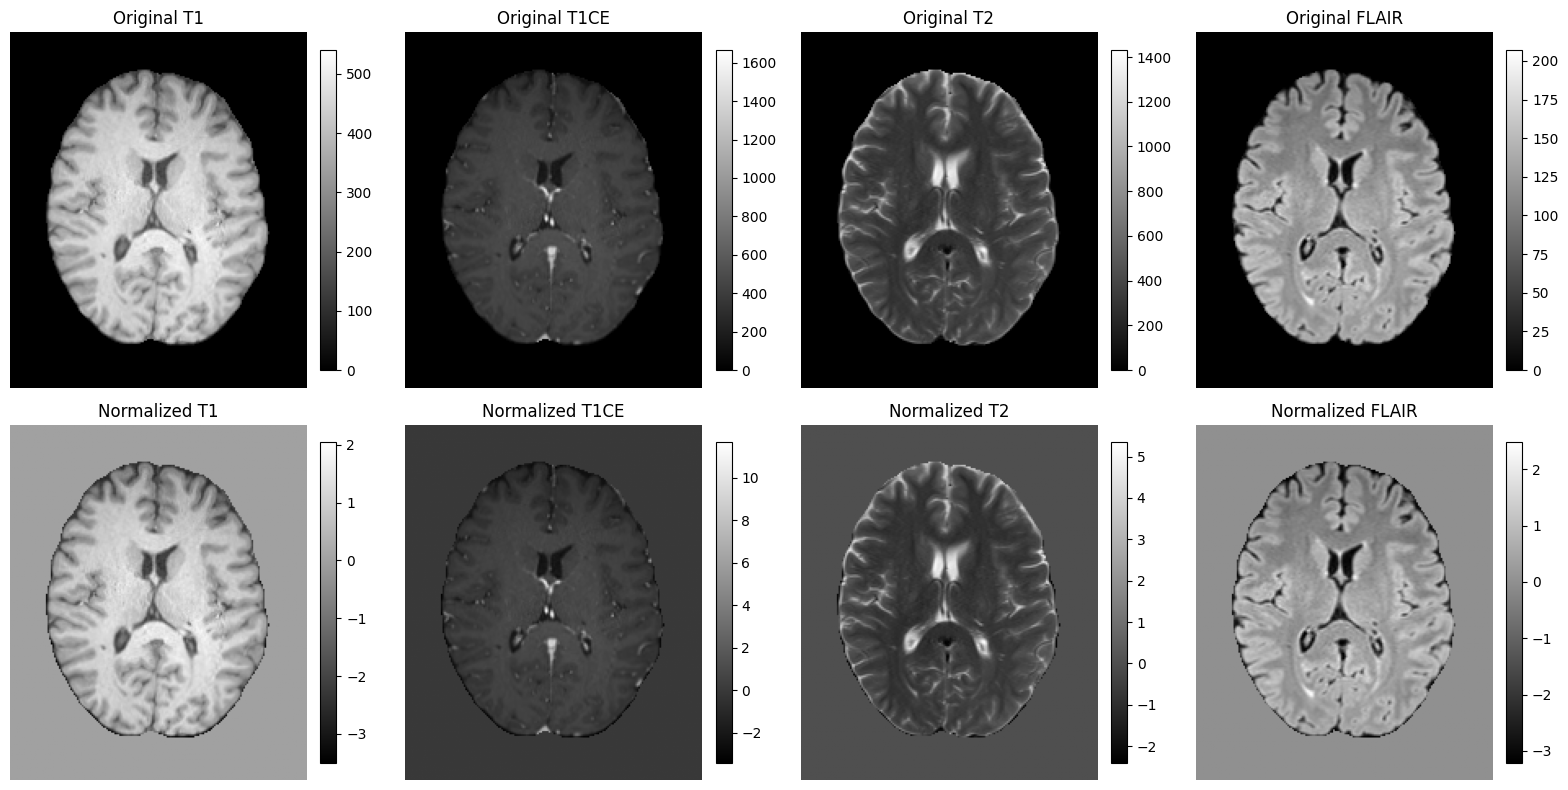

In [41]:
# Test on sample
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

modalities = ['t1', 't1ce', 't2', 'flair']
slice_num = gli_data['t1'].shape[2] // 2

for i, mod in enumerate(modalities):
    if mod in gli_data:
        # Original
        ax = axes[0, i]
        img_slice = gli_data[mod][:, :, slice_num]
        im = ax.imshow(img_slice.T, cmap='gray', origin='lower')
        ax.set_title(f'Original {mod.upper()}')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Prepcessed
        ax = axes[1, i]
        preprocessed = preprocess_image(gli_data[mod])
        img_slice = preprocessed[:, :, slice_num]
        im = ax.imshow(img_slice.T, cmap='gray', origin='lower')
        ax.set_title(f'Normalized {mod.upper()}')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/BraTS_Project/figures/GLI-preprocessing_test.png', dpi=150)
plt.show()